In [19]:
import pandas as pd
import os

# don't overwrite existing 'matches' if already loaded
if 'matches' not in globals():
    possible_paths = [r"d:\IPL_PROJECT\notebook\matches.csv", "matches.csv"]
    for p in possible_paths:
        if os.path.exists(p):
            matches = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError("matches.csv not found. Checked: " + ", ".join(possible_paths))
# don't overwrite existing 'deliveries' if already loaded
if 'deliveries' not in globals():
    possible_paths = [r"d:\IPL_PROJECT\notebook\deliveries.csv", "deliveries.csv"]
    for p in possible_paths:
        if os.path.exists(p):
            deliveries = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError("deliveries.csv not found. Checked: " + ", ".join(possible_paths))

In [13]:
matches['match_winner'].value_counts(ascending=True)

match_winner
MI      2
KKR     2
DC      3
LSG     3
CSK     3
RR      4
GT      4
SRH     5
RCB     6
PBKS    6
Name: count, dtype: int64

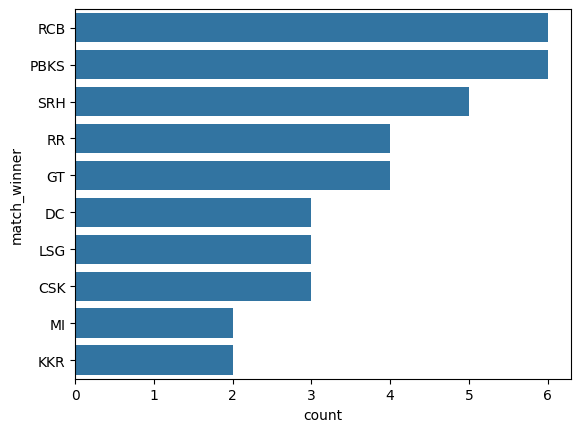

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    y=matches['match_winner'],
    order=matches['match_winner'].value_counts().index
)

plt.show()

In [9]:
(
matches['match_winner']
==
matches['toss_winner']
).mean()*100

np.float64(53.84615384615385)

In [18]:
toss_match_win = matches[
    matches['toss_winner'] == matches['match_winner']

]
print()

percentage = (
    len(toss_match_win) / len(matches)
) * 100

print(f"Percentage: {percentage:.2f}%")


Percentage: 53.85%


In [19]:
print("Total matches: ",len(matches))
print("Won Toss and Match:", len(toss_match_win))



Total matches:  39
Won Toss and Match: 21


In [21]:
(
matches['match_winner']
==
matches['toss_winner']
).mean()*100

np.float64(53.84615384615385)

In [22]:
matches['venue'].value_counts()

venue
M. Chinnaswamy Stadium, Bangalore                5
Wankhede Stadium, Mumbai                         4
Ekana Cricket Stadium, Lucknow                   4
Eden Gardens, Kolkata                            4
Arun Jaitley Stadium, Delhi                      4
Narendra Modi Stadium, Ahmedabad                 4
Rajiv Gandhi International Stadium, Hyderabad    4
Barsapara Stadium, Guwahati                      3
New PCA Cricket Stadium, Mullanpur               3
MA Chidambaram Stadium, Chennai                  3
Sawai Mansingh Stadium, Jaipur                   1
Name: count, dtype: int64

In [28]:
deliveries.columns.tolist()

['match_no',
 'date',
 'stage',
 'venue',
 'batting_team',
 'bowling_team',
 'innings',
 'over',
 'striker',
 'bowler',
 'runs_of_bat',
 'extras',
 'wide',
 'legbyes',
 'byes',
 'noballs',
 'wicket_type',
 'player_dismissed',
 'fielder']

In [3]:
top_batsmen = deliveries.groupby(
    'striker'
)['noballs'].sum()

top_batsmen.sort_values(ascending=False).head(10)

striker
Himmat Singh         4
Sanju Samson         3
Sai Sudharsan        3
Tim David            3
Prabhsimran Singh    2
Anshul Kamboj        2
Ashutosh Sharma      2
Cooper Connolly      2
Shreyas Iyer         2
Mitchell Marsh       2
Name: noballs, dtype: int64

In [4]:
deliveries.groupby('bowler')['player_dismissed'] \
          .count() \
          .sort_values(ascending=False) \
          .head(10)

bowler
Bhuvneshwar Kumar    29
Jofra Archer         29
Kagiso Rabada        29
Anshul Kamboj        24
Eshan Malinga        21
Rashid Khan          21
Mohammed Siraj       20
Rasikh Salam Dar     20
Prince Yadav         20
Kartik Tyagi         19
Name: player_dismissed, dtype: int64

In [9]:
def top_batsmen(deliveries):

    return (
        deliveries
        .groupby('striker')
        ['runs_of_bat']
        .sum()
        .sort_values(ascending=False)
    )

In [10]:
top_batsmen(deliveries)

striker
Vaibhav Sooryavanshi    776
Shubman Gill            732
Sai Sudharsan           722
Virat Kohli             675
Heinrich Klaasen        624
                       ... 
KL Rahul                  0
Josh Hazlewood            0
Mohsin Khan               0
Ravi Bishnoi              0
Spencer Johnson           0
Name: runs_of_bat, Length: 177, dtype: int64

In [12]:
top_batsmen(deliveries).head(10)

striker
Vaibhav Sooryavanshi    776
Shubman Gill            732
Sai Sudharsan           722
Virat Kohli             675
Heinrich Klaasen        624
Ishan Kishan            604
Rahul                   593
Mitchell Marsh          563
Abhishek Sharma         563
Jos Buttler             526
Name: runs_of_bat, dtype: int64